# Sistema Inteligente de Recomendación Alimenticia

**Curso:** Inteligencia Artificial — Principios y Técnicas (ISIA-108)  
**Universidad:** UPAO — Semestre 2026-10  

Este notebook ejecuta el sistema completo desde Google Colab.  
Para versión modular en VS Code, ver el repositorio `proyecto_ia/`.

---

## Arquitectura

| Capa | Técnica |
|---|---|
| 1 | Cálculo nutricional (Mifflin-St Jeor)|
| 2 | Sistema Experto (18 reglas)|
| 3 | K-Means | Sem. 9 | RA2.1 |
| 4 | Optimización con PuLP |
| 5 | LLM *(pendiente)* |

## Celda 1 — Setup del entorno

Instala dependencias y monta Google Drive para acceder al dataset.

In [30]:
# Instalación de librerías necesarias
!pip install -q pulp

# Imports principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 30)

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

print('✓ Entorno listo')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Entorno listo


## Celda 2 — Carga del dataset

Carga los 81 ingredientes curados desde Drive. Ajusta la ruta si es necesario.

In [31]:
# Ruta al dataset en tu Drive
RUTA_DATASET = '/content/drive/MyDrive/proyecto_ia/ingredientes_dataset.csv'

df_ingredientes = pd.read_csv(RUTA_DATASET, encoding='utf-8-sig')

# Validaciones rápidas
assert len(df_ingredientes) > 0
assert 'calorias' in df_ingredientes.columns
assert df_ingredientes['id'].is_unique

print(f'✓ Dataset cargado: {len(df_ingredientes)} ingredientes, {df_ingredientes.shape[1]} columnas')
df_ingredientes.head()

✓ Dataset cargado: 81 ingredientes, 20 columnas


,id,nombre,nombre_en,categoria,estado,tipo_uso,grupo_intercambiable,calorias,proteina_g,carbohidratos_g,grasa_g,fibra_g,azucar_g,grasa_saturada_g,sodio_mg,indice_glucemico,tipo_proteina,apto_vegetariano,apto_vegano,comidas_recomendadas
0,1,Pollo,Chicken breast (cooked),Proteina,cocido,principal,ave,220,41.3,0.0,4.8,0.0,0.0,1.3,99,ninguno,animal,False,False,"desayuno,almuerzo,cena"
1,2,Pavo,Turkey breast (cooked),Proteina,cocido,principal,ave,180,40.0,0.0,1.3,0.0,0.0,0.4,133,ninguno,animal,False,False,"desayuno,almuerzo,cena"
2,3,Carne molida,Ground beef 80/20 (cooked),Proteina,cocido,principal,carne_roja,290,26.5,0.0,20.0,0.0,0.0,7.7,75,ninguno,animal,False,False,"almuerzo,cena"
3,4,Bistec,Beef sirloin steak (cooked),Proteina,cocido,principal,carne_roja,222,31.0,0.0,10.6,0.0,0.0,4.1,60,ninguno,animal,False,False,"almuerzo,cena"
4,5,Lomo de res,Beef tenderloin (cooked),Proteina,cocido,principal,carne_roja,247,30.0,0.0,13.2,0.0,0.0,5.0,55,ninguno,animal,False,False,"almuerzo,cena"


## Celda 3 — Análisis exploratorio (EDA)

Distribución por categoría y aptitud para dietas. Justifica el trabajo de Semana 5.

Distribución por categoría:
categoria
Carbohidrato    19
Fruta           17
Proteina        14
Verdura         12
Grasa            7
Condimento       5
Lacteo           4
Bebida           3
Name: count, dtype: int64


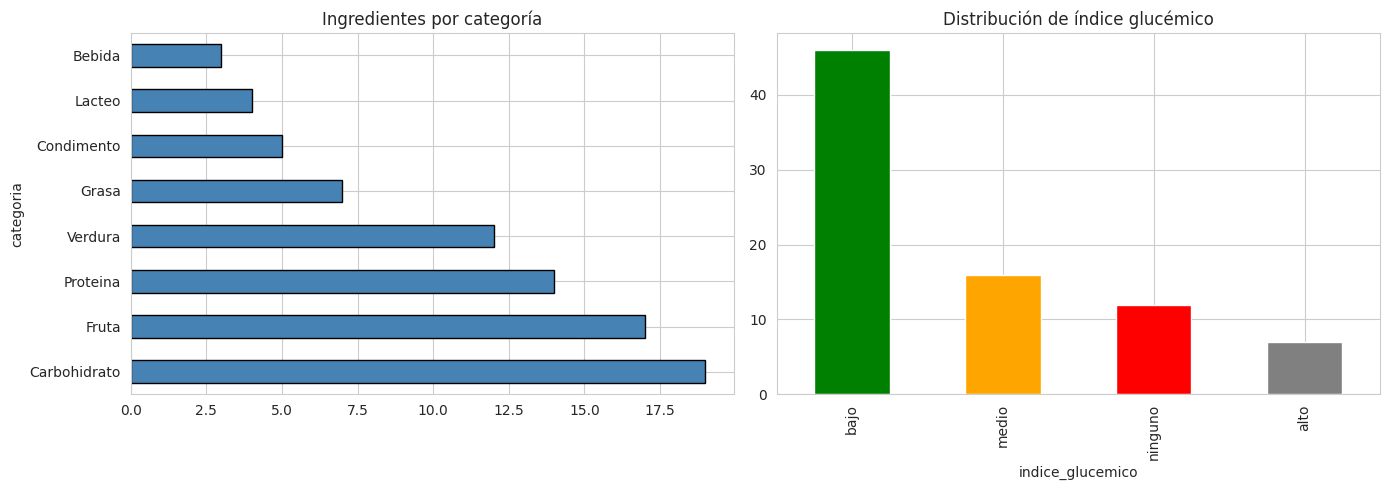

In [32]:
# Información estructural
print('Distribución por categoría:')
print(df_ingredientes['categoria'].value_counts())

# Visualización rápida
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_ingredientes['categoria'].value_counts().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Ingredientes por categoría')
df_ingredientes['indice_glucemico'].value_counts().plot(
    kind='bar', ax=axes[1], color=['green', 'orange', 'red', 'gray'])
axes[1].set_title('Distribución de índice glucémico')
plt.tight_layout()
plt.show()

## Celda 4 — Cálculo nutricional

Implementa Mifflin-St Jeor para TMB y aplica factores de actividad para GET.

In [33]:
# Factores de actividad física (estándar OMS)
FACTORES_ACTIVIDAD = {
    'sedentario':  1.20, 'ligero': 1.375, 'moderado': 1.55,
    'intenso':     1.725, 'muy_intenso': 1.90,
}

def calcular_tmb(peso_kg, altura_cm, edad, sexo):
    """TMB con Mifflin-St Jeor (más precisa que Harris-Benedict)."""
    if sexo.upper() == 'M':
        return 10 * peso_kg + 6.25 * altura_cm - 5 * edad + 5
    elif sexo.upper() == 'F':
        return 10 * peso_kg + 6.25 * altura_cm - 5 * edad - 161
    raise ValueError(f"Sexo debe ser 'M' o 'F': {sexo}")

def calcular_get(tmb, nivel_actividad):
    """GET = TMB × factor de actividad."""
    return tmb * FACTORES_ACTIVIDAD[nivel_actividad]

# Prueba
tmb_test = calcular_tmb(75, 175, 25, 'M')
print(f'TMB: {tmb_test:.0f} | GET: {calcular_get(tmb_test, "moderado"):.0f}')

TMB: 1724 | GET: 2672


## Celda 5 — Reparto de macros (Reglas B1, B2, B3 + F1)

Define cuántos gramos de cada macro por objetivo y aplica la regla de seguridad calórica.

In [34]:
# Reglas B1, B2, B3: macros según objetivo
REGLAS_OBJETIVO = {
    'perder_grasa':  {'ajuste_calorico': 0.80, 'pct_proteina': 0.40, 'pct_carbos': 0.35, 'pct_grasa': 0.25},
    'mantener':      {'ajuste_calorico': 1.00, 'pct_proteina': 0.30, 'pct_carbos': 0.45, 'pct_grasa': 0.25},
    'ganar_musculo': {'ajuste_calorico': 1.15, 'pct_proteina': 0.35, 'pct_carbos': 0.40, 'pct_grasa': 0.25},
}

# Distribución de calorías entre comidas según objetivo
DISTRIBUCION_POR_OBJETIVO = {
    'perder_grasa':  {'desayuno': 0.25, 'almuerzo': 0.35, 'cena': 0.30, 'snack': 0.10},
    'mantener':      {'desayuno': 0.25, 'almuerzo': 0.30, 'cena': 0.30, 'snack': 0.15},
    'ganar_musculo': {'desayuno': 0.22, 'almuerzo': 0.33, 'cena': 0.30, 'snack': 0.15},
}

KCAL_POR_GRAMO = {'proteina': 4, 'carbos': 4, 'grasa': 9}

# Regla F1: mínimo calórico de seguridad
MINIMO_KCAL_SEGURIDAD = {'M': 1500, 'F': 1200}

def calcular_targets_diarios(get, objetivo, sexo='M'):
    """Calcula calorías y macros aplicando B1/B2/B3 y F1."""
    regla = REGLAS_OBJETIVO[objetivo]
    cal_calc = get * regla['ajuste_calorico']
    minimo = MINIMO_KCAL_SEGURIDAD.get(sexo.upper(), 1200)
    advertencia = cal_calc < minimo
    cal_final = max(cal_calc, minimo)
    return {
        'calorias_objetivo':            round(cal_final),
        'calorias_calculadas':          round(cal_calc),
        'proteina_g': round(cal_final * regla['pct_proteina'] / 4),
        'carbos_g':   round(cal_final * regla['pct_carbos']   / 4),
        'grasa_g':    round(cal_final * regla['pct_grasa']    / 9),
        'objetivo':                     objetivo,
        'advertencia_minimo_seguridad': advertencia,
    }

def repartir_por_comida(targets):
    """Reparte targets entre las 4 comidas según el objetivo."""
    distribucion = DISTRIBUCION_POR_OBJETIVO[targets['objetivo']]
    return {
        c: {
            'calorias_objetivo': round(targets['calorias_objetivo'] * f),
            'proteina_g':        round(targets['proteina_g'] * f),
            'carbos_g':          round(targets['carbos_g'] * f),
            'grasa_g':           round(targets['grasa_g'] * f),
        } for c, f in distribucion.items()
    }

print('✓ Reparto de macros y regla F1 listos')

✓ Reparto de macros y regla F1 listos


## Celda 6 — Perfil del usuario

Clase que valida y encapsula los datos del usuario. Diseñada modularmente.

In [35]:
class PerfilUsuario:
    """Datos del usuario. v1.0 solo soporta dieta omnívora."""

    OPCIONES_VALIDAS = {
        'sexo':            ['M', 'F'],
        'nivel_actividad': list(FACTORES_ACTIVIDAD.keys()),
        'objetivo':        list(REGLAS_OBJETIVO.keys()),
    }

    def __init__(self, edad, sexo, peso_kg, altura_cm, nivel_actividad, objetivo):
        # Validaciones de rango
        if not (10 <= edad <= 100): raise ValueError(f'Edad fuera de rango: {edad}')
        if not (30 <= peso_kg <= 250): raise ValueError(f'Peso fuera de rango: {peso_kg}')
        if not (100 <= altura_cm <= 230): raise ValueError(f'Altura fuera de rango: {altura_cm}')
        for campo, opciones in self.OPCIONES_VALIDAS.items():
            if locals()[campo] not in opciones:
                raise ValueError(f"'{campo}' inválido")
        self.edad, self.sexo = edad, sexo.upper()
        self.peso_kg, self.altura_cm = peso_kg, altura_cm
        self.nivel_actividad = nivel_actividad
        self.objetivo = objetivo

    def calcular_targets(self):
        tmb = calcular_tmb(self.peso_kg, self.altura_cm, self.edad, self.sexo)
        get = calcular_get(tmb, self.nivel_actividad)
        targets = calcular_targets_diarios(get, self.objetivo, sexo=self.sexo)
        targets['tmb'], targets['get'] = round(tmb), round(get)
        return targets

    def __repr__(self):
        return (f'PerfilUsuario(edad={self.edad}, sexo={self.sexo}, '
                f'{self.peso_kg}kg, {self.altura_cm}cm, '
                f'actividad={self.nivel_actividad}, objetivo={self.objetivo})')


def crear_perfil_manual(edad, sexo, peso_kg, altura_cm, nivel_actividad, objetivo):
    """Crea un perfil desde input manual. Punto de extensión para futuras fuentes."""
    return PerfilUsuario(edad, sexo, peso_kg, altura_cm, nivel_actividad, objetivo)


# Caso de prueba: nuestro usuario demo
usuario_demo = crear_perfil_manual(
    edad=25, sexo='M', peso_kg=75, altura_cm=175,
    nivel_actividad='moderado', objetivo='ganar_musculo'
)
print(usuario_demo)
print(usuario_demo.calcular_targets())

PerfilUsuario(edad=25, sexo=M, 75kg, 175cm, actividad=moderado, objetivo=ganar_musculo)
{'calorias_objetivo': 3073, 'calorias_calculadas': 3073, 'proteina_g': 269, 'carbos_g': 307, 'grasa_g': 85, 'objetivo': 'ganar_musculo', 'advertencia_minimo_seguridad': False, 'tmb': 1724, 'get': 2672}


## Celda 7 — Sistema Experto (Capa 2 - RA1.2)

Motor de inferencia con 18 reglas distribuidas en 5 grupos.  
Filtra y pondera ingredientes según el perfil + comida.

In [38]:
class SistemaExperto:
    """Motor de inferencia basado en reglas."""

    # Estructura obligatoria por comida (Reglas C1-C4)
    ESTRUCTURA_POR_COMIDA = {
        'desayuno': {'obligatorios': ['Carbohidrato']},
        'almuerzo': {'obligatorios': ['Proteina', 'Carbohidrato', 'Verdura']},
        'cena':     {'obligatorios': ['Proteina', 'Verdura']},
        'snack':    {'obligatorios': []},
    }

    INGREDIENTES_SALUDABLES_MAYORES = [
        'Palta', 'Nueces', 'Chia', 'Salmon', 'Jurel', 'Caballa', 'Almendras'
    ]

    def __init__(self, df_ingredientes):
        self.df_original = df_ingredientes.copy()
        self.reglas_aplicadas = []

    # GRUPO D — Reglas de salud (SOFT, modifican pesos)
    def _aplicar_reglas_salud(self, df, perfil):
        # D1: perder grasa → desincentivar grasas saturadas altas
        if perfil.objetivo == 'perder_grasa':
            mask = df['grasa_saturada_g'] > 7
            df.loc[mask, 'peso'] *= 0.5
            if mask.any():
                self.reglas_aplicadas.append(f'D1: peso×0.5 a {mask.sum()} ingredientes con grasa sat. >7g')
        # D3: ganar músculo → priorizar proteínas con ≥25g
        if perfil.objetivo == 'ganar_musculo':
            mask = (df['categoria'] == 'Proteina') & (df['proteina_g'] >= 25)
            df.loc[mask, 'peso'] *= 1.5
            if mask.any():
                self.reglas_aplicadas.append(f'D3: peso×1.5 a {mask.sum()} proteínas con ≥25g/100g')
        # D4 y D5: ajustes para edad > 50
        if perfil.edad > 50:
            mask_d4 = df['grasa_saturada_g'] > 5
            df.loc[mask_d4, 'peso'] *= 0.5
            if mask_d4.any():
                self.reglas_aplicadas.append(f'D4: peso×0.5 a {mask_d4.sum()} ingredientes (edad>50)')
            mask_d5 = df['nombre'].isin(self.INGREDIENTES_SALUDABLES_MAYORES)
            df.loc[mask_d5, 'peso'] *= 1.5
            if mask_d5.any():
                self.reglas_aplicadas.append(f'D5: peso×1.5 a {mask_d5.sum()} grasas saludables')
        return df

    # GRUPO E — Contexto del momento (SOFT)
    def _aplicar_reglas_contexto(self, df, perfil, comida):
        if comida == 'desayuno' and perfil.objetivo == 'ganar_musculo':
            self.reglas_aplicadas.append('E1: carnes habilitadas en desayuno')
        if comida == 'snack':
            mask = df['comidas_recomendadas'].str.contains('snack', na=False)
            df.loc[mask, 'peso'] *= 1.5
            if mask.any():
                self.reglas_aplicadas.append(f'E2: peso×1.5 a {mask.sum()} ingredientes para snack')
        if comida == 'cena' and perfil.objetivo == 'perder_grasa':
            mask_p = df['grupo_intercambiable'].isin(['pescado_magro', 'hoja_verde'])
            df.loc[mask_p, 'peso'] *= 1.5
            mask_d = df['grupo_intercambiable'] == 'carne_roja'
            df.loc[mask_d, 'peso'] *= 0.7
            self.reglas_aplicadas.append('E3: cena light → +pescado/hojas, -carnes')
        return df

    def _filtrar_por_momento(self, df, comida):
        if comida is None: return df
        return df[df['comidas_recomendadas'].str.contains(comida, na=False)]

    def evaluar(self, perfil, comida):
        """Ejecuta todas las reglas y devuelve outputs estructurados."""
        self.reglas_aplicadas = []
        df = self.df_original.copy()
        df['peso'] = 1.0
        # Separar condimentos (no entran en optimización)
        df_condimentos = df[df['tipo_uso'] == 'condimento'].copy()
        df = df[df['tipo_uso'] == 'principal'].copy()
        # Pipeline de reglas
        df = self._filtrar_por_momento(df, comida)
        df = self._aplicar_reglas_salud(df, perfil)
        df = self._aplicar_reglas_contexto(df, perfil, comida)
        # Targets de la comida
        targets_diarios = perfil.calcular_targets()
        targets_comida = repartir_por_comida(targets_diarios)[comida]
        return {
            'ingredientes_principales': df.reset_index(drop=True),
            'condimentos':              df_condimentos.reset_index(drop=True),
            'estructura':               self.ESTRUCTURA_POR_COMIDA.get(comida, {'obligatorios': []}),
            'targets':                  targets_comida,
            'reglas_log':               self.reglas_aplicadas.copy(),
            'comida':                   comida,
        }


# Inicializar el sistema con el dataset
sistema = SistemaExperto(df_ingredientes)

# Probar con el usuario demo, comida = almuerzo
resultado = sistema.evaluar(usuario_demo, 'almuerzo')
print(f'Ingredientes válidos: {len(resultado["ingredientes_principales"])}')
print(f'Reglas aplicadas:')
for r in resultado['reglas_log']:
    print(f'  • {r}')

Ingredientes válidos: 42
Reglas aplicadas:
  • D3: peso×1.5 a 9 proteínas con ≥25g/100g


## Celda 9 — Optimización con PuLP (Capa 4 - RA1.1)

Programación lineal mixta entera con fallback automático.  
Encuentra la combinación óptima de ingredientes y cantidades.

In [39]:
from pulp import LpProblem, LpMinimize, LpVariable, LpStatus, lpSum, value, PULP_CBC_CMD

# Configuración: porciones en gramos por categoría (comidas principales)
PORCIONES_BASE = {
    'Proteina':     {'min': 80,  'max': 250},
    'Carbohidrato': {'min': 30,  'max': 220},
    'Verdura':      {'min': 50,  'max': 150},
    'Grasa':        {'min': 15,  'max': 60},
    'Lacteo':       {'min': 30,  'max': 300},
    'Bebida':       {'min': 100, 'max': 400},
    'Fruta':        {'min': 50,  'max': 250},
}
MAX_POR_CATEGORIA_BASE = {
    'Proteina': 1, 'Carbohidrato': 1, 'Grasa': 1,
    'Lacteo': 1, 'Bebida': 1, 'Fruta': 1, 'Verdura': 2,
}

# Configuración del snack (contextual por objetivo)
PORCIONES_SNACK = {
    'perder_grasa': {
        'Fruta': {'min': 80, 'max': 200}, 'Lacteo': {'min': 80, 'max': 150},
        'Verdura': {'min': 50, 'max': 100}, 'Grasa': {'min': 10, 'max': 20}},
    'mantener': {
        'Fruta': {'min': 80, 'max': 200}, 'Lacteo': {'min': 80, 'max': 200},
        'Grasa': {'min': 15, 'max': 30}, 'Proteina': {'min': 30, 'max': 100}},
    'ganar_musculo': {
        'Proteina': {'min': 80, 'max': 150}, 'Lacteo': {'min': 80, 'max': 120},
        'Fruta': {'min': 80, 'max': 200}, 'Carbohidrato': {'min': 30, 'max': 60}},
}
MAX_POR_CATEGORIA_SNACK = {
    'perder_grasa':  {'Fruta': 1, 'Lacteo': 1, 'Verdura': 1, 'Grasa': 1},
    'mantener':      {'Fruta': 1, 'Lacteo': 1, 'Grasa': 1, 'Proteina': 1},
    'ganar_musculo': {'Proteina': 1, 'Lacteo': 1, 'Fruta': 1, 'Carbohidrato': 1},
}
CATEGORIAS_SNACK = {
    'perder_grasa':  ['Fruta', 'Lacteo', 'Verdura', 'Grasa'],
    'mantener':      ['Fruta', 'Lacteo', 'Grasa', 'Proteina'],
    'ganar_musculo': ['Proteina', 'Lacteo', 'Fruta', 'Carbohidrato'],
}

# Desayuno: sin verduras
CATEGORIAS_DESAYUNO = ['Carbohidrato', 'Proteina', 'Lacteo', 'Grasa', 'Fruta', 'Bebida']
GRUPOS_PROTEINA_RAPIDA = ['huevo', 'yogurt', 'suplemento', 'queso']

# Límites de cantidad de ingredientes (evita combinaciones tipo buffet)
LIMITE_INGREDIENTES = {
    'perder_grasa':  {'desayuno': 3, 'almuerzo': 4, 'cena': 3, 'snack': 2},
    'mantener':      {'desayuno': 3, 'almuerzo': 4, 'cena': 3, 'snack': 2},
    'ganar_musculo': {'desayuno': 4, 'almuerzo': 5, 'cena': 4, 'snack': 3},
}

# Otras constantes del solver
PCT_PROTEINA_FORZADA   = 0.70
TOLERANCIA_CALORIAS    = 0.10
TOLERANCIA_MACROS      = 0.20
LAMBDA_BONUS           = 1.0
INCREMENTO_FALLBACK    = 1
MAX_INTENTOS_FALLBACK  = 2


def _construir_y_resolver(df, estructura, targets, es_snack,
                          porciones_config, max_cat_config, max_ingredientes):
    """Construye el modelo PuLP y lo resuelve."""
    prob = LpProblem('Plan_Comida', LpMinimize)
    # Variables: x (gramos) y b (binaria de uso)
    x, b = {}, {}
    for _, row in df.iterrows():
        idx, cat = row['id'], row['categoria']
        cfg = porciones_config.get(cat, {'min': 20, 'max': 200})
        x[idx] = LpVariable(f'x_{idx}', lowBound=0, upBound=cfg['max'])
        b[idx] = LpVariable(f'b_{idx}', cat='Binary')
        prob += x[idx] >= cfg['min'] * b[idx], f'min_si_usado_{idx}'
        prob += x[idx] <= cfg['max'] * b[idx], f'max_si_usado_{idx}'
    # Totales de macros
    def total(col):
        return lpSum((row[col] / 100) * x[row['id']] for _, row in df.iterrows())
    total_kcal, total_p = total('calorias'), total('proteina_g')
    total_c, total_g    = total('carbohidratos_g'), total('grasa_g')
    # Restricciones de macros con tolerancia
    tk, tp, tc, tg = (targets['calorias_objetivo'], targets['proteina_g'],
                     targets['carbos_g'], targets['grasa_g'])
    prob += total_kcal >= tk * (1 - TOLERANCIA_CALORIAS), 'kcal_min'
    prob += total_kcal <= tk * (1 + TOLERANCIA_CALORIAS), 'kcal_max'
    prob += total_p >= tp * (1 - TOLERANCIA_MACROS), 'prot_min'
    prob += total_p <= tp * (1 + TOLERANCIA_MACROS), 'prot_max'
    prob += total_c >= tc * (1 - TOLERANCIA_MACROS), 'carb_min'
    prob += total_c <= tc * (1 + TOLERANCIA_MACROS), 'carb_max'
    prob += total_g >= tg * (1 - TOLERANCIA_MACROS), 'grasa_min'
    prob += total_g <= tg * (1 + TOLERANCIA_MACROS), 'grasa_max'
    # En comidas principales: forzar densidad proteica
    if not es_snack:
        prot_principales = lpSum((row['proteina_g'] / 100) * x[row['id']]
                                  for _, row in df.iterrows()
                                  if row['categoria'] in ('Proteina', 'Lacteo'))
        prob += prot_principales >= tp * PCT_PROTEINA_FORZADA, 'min_prot_real'
        # Estructura obligatoria
        for cat_oblig in estructura.get('obligatorios', []):
            ids_cat = df[df['categoria'] == cat_oblig]['id'].tolist()
            if ids_cat:
                prob += lpSum(b[i] for i in ids_cat) >= 1, f'min_un_{cat_oblig}'
    # Máximo por categoría
    for categoria in df['categoria'].unique():
        ids_cat = df[df['categoria'] == categoria]['id'].tolist()
        max_perm = max_cat_config.get(categoria, 1)
        if len(ids_cat) > max_perm:
            prob += lpSum(b[i] for i in ids_cat) <= max_perm, f'max_{categoria}'
    # Máximo 1 por grupo intercambiable
    for grupo in df['grupo_intercambiable'].dropna().unique():
        ids_grupo = df[df['grupo_intercambiable'] == grupo]['id'].tolist()
        if len(ids_grupo) > 1:
            prob += lpSum(b[i] for i in ids_grupo) <= 1, f'max_grupo_{grupo}'
    # Solo 1 entre Bebida y Lácteo
    ids_bl = df[df['categoria'].isin(['Bebida', 'Lacteo'])]['id'].tolist()
    if len(ids_bl) > 1:
        prob += lpSum(b[i] for i in ids_bl) <= 1, 'max_un_liquido'
    # Límite total de ingredientes (anti-buffet)
    todos_ids = df['id'].tolist()
    if len(todos_ids) > max_ingredientes:
        prob += lpSum(b[i] for i in todos_ids) <= max_ingredientes, 'limite_total'
    # Función objetivo: minimizar desviaciones - λ × bonus
    dev_p = LpVariable('dev_prot', lowBound=0)
    dev_c = LpVariable('dev_carb', lowBound=0)
    dev_g = LpVariable('dev_grasa', lowBound=0)
    prob += dev_p >= total_p - tp; prob += dev_p >= -(total_p - tp)
    prob += dev_c >= total_c - tc; prob += dev_c >= -(total_c - tc)
    prob += dev_g >= total_g - tg; prob += dev_g >= -(total_g - tg)
    bonus = lpSum(row['peso'] * x[row['id']] / 100 for _, row in df.iterrows())
    prob += dev_p + dev_c + dev_g - LAMBDA_BONUS * bonus
    prob.solve(PULP_CBC_CMD(msg=0))
    return LpStatus[prob.status], x, b


def optimizar_comida(resultado_experto, objetivo_usuario='mantener'):
    """Resuelve la optimización con fallback automático si es infactible."""
    df_original = resultado_experto['ingredientes_principales']
    estructura  = resultado_experto['estructura']
    targets     = resultado_experto['targets']
    comida      = resultado_experto.get('comida', 'almuerzo')
    if len(df_original) == 0:
        return {'estado': 'infactible', 'mensaje': 'No hay ingredientes válidos'}
    es_snack    = (comida == 'snack')
    es_desayuno = (comida == 'desayuno')
    # Configuración según comida
    if es_snack:
        porciones_config = PORCIONES_SNACK.get(objetivo_usuario, PORCIONES_SNACK['mantener'])
        max_cat_config   = MAX_POR_CATEGORIA_SNACK.get(objetivo_usuario, {})
        cats_permitidas  = CATEGORIAS_SNACK.get(objetivo_usuario, ['Fruta', 'Lacteo'])
        df = df_original[df_original['categoria'].isin(cats_permitidas)].copy()
        # Excluir ingredientes que requieren preparación
        df = df[~df['grupo_intercambiable'].isin(
            ['legumbre_proteica', 'legumbre', 'grano_andino', 'tuberculo'])]
        # Priorizar proteínas rápidas si es ganar músculo
        if objetivo_usuario == 'ganar_musculo':
            mask = df['grupo_intercambiable'].isin(GRUPOS_PROTEINA_RAPIDA)
            df.loc[mask, 'peso'] *= 1.5
    elif es_desayuno:
        porciones_config = PORCIONES_BASE
        max_cat_config   = MAX_POR_CATEGORIA_BASE
        df = df_original[df_original['categoria'].isin(CATEGORIAS_DESAYUNO)].copy()
        df = df[(df['grupo_intercambiable'] != 'tuberculo') | (df['nombre'] == 'Camote')]
    else:
        porciones_config = PORCIONES_BASE
        max_cat_config   = MAX_POR_CATEGORIA_BASE
        df = df_original.copy()
    if len(df) == 0:
        return {'estado': 'infactible', 'mensaje': f'Sin ingredientes para {comida}'}
    # Fallback automático
    limite_inicial = LIMITE_INGREDIENTES.get(objetivo_usuario, {}).get(comida, 4)
    estado_final, x_final = None, None
    intento_final, fallback = 0, False
    for intento in range(MAX_INTENTOS_FALLBACK + 1):
        max_ing = limite_inicial + (intento * INCREMENTO_FALLBACK)
        estado, x, b = _construir_y_resolver(df, estructura, targets, es_snack,
                                              porciones_config, max_cat_config, max_ing)
        if estado == 'Optimal':
            estado_final, x_final, intento_final = estado, x, intento
            fallback = (intento > 0)
            break
    if estado_final != 'Optimal':
        return {'estado': 'infactible', 'mensaje': f'Infactible tras reintentos', 'targets': targets}
    # Extraer solución
    plan = []
    for _, row in df.iterrows():
        gramos = value(x_final[row['id']])
        if gramos and gramos > 0.5:
            plan.append({
                'nombre': row['nombre'], 'categoria': row['categoria'],
                'gramos': round(gramos),
                'kcal':     round((row['calorias']        / 100) * gramos),
                'proteina': round((row['proteina_g']      / 100) * gramos, 1),
                'carbos':   round((row['carbohidratos_g'] / 100) * gramos, 1),
                'grasa':    round((row['grasa_g']         / 100) * gramos, 1),
            })
    totales = {
        'kcal':     round(sum(p['kcal']     for p in plan)),
        'proteina': round(sum(p['proteina'] for p in plan), 1),
        'carbos':   round(sum(p['carbos']   for p in plan), 1),
        'grasa':    round(sum(p['grasa']    for p in plan), 1),
    }
    desv = {
        k: round((totales[k if k != 'kcal' else 'kcal'] - targets[f'{k}_g' if k != 'kcal' else 'calorias_objetivo'])
                 / targets[f'{k}_g' if k != 'kcal' else 'calorias_objetivo'] * 100, 1)
        for k in ['kcal', 'proteina', 'carbos', 'grasa']
    }
    return {
        'estado': 'optimo', 'plan': plan, 'totales': totales,
        'targets': targets, 'desviaciones': desv, 'comida': comida,
        'limite_aplicado': limite_inicial + (intento_final * INCREMENTO_FALLBACK),
        'fallback_aplicado': fallback,
    }

print('✓ Optimizador con PuLP listo')

✓ Optimizador con PuLP listo


## Celda 9b — Validación con perfiles diversos

Genera planes diarios completos para 4 perfiles representativos.

In [40]:
PERFILES_DE_PRUEBA = [
    ('Hombre joven, ganar músculo (caso de referencia)',
     crear_perfil_manual(25, 'M', 75, 175, 'moderado', 'ganar_musculo')),
    ('Mujer adulta, perder grasa, sedentaria',
     crear_perfil_manual(35, 'F', 65, 162, 'sedentario', 'perder_grasa')),
    ('Hombre adulto mayor, mantener peso, activo',
     crear_perfil_manual(55, 'M', 80, 170, 'ligero', 'mantener')),
    ('Mujer joven activa, ganar músculo',
     crear_perfil_manual(22, 'F', 58, 165, 'intenso', 'ganar_musculo')),
]

for nombre, perfil in PERFILES_DE_PRUEBA:
    print('\n' + '█' * 70)
    print(f'  {nombre}')
    print('█' * 70)
    print(f'  {perfil}')
    targets_dia = perfil.calcular_targets()
    print(f'  TMB: {targets_dia["tmb"]} | GET: {targets_dia["get"]} | '
          f'Objetivo: {targets_dia["calorias_objetivo"]} kcal')
    soluciones = []
    for comida in ['desayuno', 'almuerzo', 'cena', 'snack']:
        resultado = sistema.evaluar(perfil, comida)
        sol = optimizar_comida(resultado, objetivo_usuario=perfil.objetivo)
        print(f'\n  ─── {comida.upper()} ───')
        if sol['estado'] != 'optimo':
            print(f'  ⚠ {sol.get("mensaje", "infactible")}'); continue
        for item in sol['plan']:
            print(f'    • {item["nombre"]:<22} ({item["categoria"]:<13}) '
                  f'{item["gramos"]:>3}g → {item["kcal"]:>4} kcal')
        peso = sum(p['gramos'] for p in sol['plan'])
        print(f'    Target: {sol["targets"]["calorias_objetivo"]} kcal | '
              f'Real: {sol["totales"]["kcal"]} kcal | Peso: {peso}g')
        soluciones.append(sol)
    if len(soluciones) == 4:
        kcal = sum(s['totales']['kcal'] for s in soluciones)
        desv = (kcal - targets_dia['calorias_objetivo']) / targets_dia['calorias_objetivo'] * 100
        print(f'\n  RESUMEN: {kcal} kcal (target: {targets_dia["calorias_objetivo"]}) | Desv: {desv:+.1f}%')


██████████████████████████████████████████████████████████████████████
  Hombre joven, ganar músculo (caso de referencia)
██████████████████████████████████████████████████████████████████████
  PerfilUsuario(edad=25, sexo=M, 75kg, 175cm, actividad=moderado, objetivo=ganar_musculo)
  TMB: 1724 | GET: 2672 | Objetivo: 3073 kcal

  ─── DESAYUNO ───
    • Pollo                  (Proteina     ) 118g →  260 kcal
    • Kiwicha                (Carbohidrato ) 199g →  203 kcal
    • Bebida de coco         (Bebida       ) 400g →  124 kcal
    • Fresas                 (Fruta        ) 250g →   80 kcal
    Target: 676 kcal | Real: 667 kcal | Peso: 967g

  ─── ALMUERZO ───
    • Bistec                 (Proteina     ) 250g →  554 kcal
    • Yuca                   (Carbohidrato ) 220g →  352 kcal
    • Espinaca               (Verdura      ) 150g →   34 kcal
    • Brocoli                (Verdura      ) 150g →   51 kcal
    Target: 1014 kcal | Real: 991 kcal | Peso: 770g

  ─── CENA ───
    • Bistec   

###CELDA 11 — Orquestador del Plan Diario

Coordina la generación de las 4 comidas como un día completo, manteniendo memoria de ingredientes usados para evitar repeticiones poco realistas entre comidas.
Estrategia: penalización suave (peso × 0.3) a ingredientes ya usados. Pueden reaparecer si no hay alternativas, peroel optimizador prefiere variar.

In [41]:
ORDEN_GENERACION = ['almuerzo', 'cena', 'desayuno', 'snack']
FACTOR_PENALIZACION = 0.3


class OrquestadorDiario:
    """Genera un plan alimenticio completo con coherencia entre comidas.

    Mantiene un registro de ingredientes ya usados en el día y aplica
    penalización suave en comidas posteriores para promover variedad.
    """

    def __init__(self, sistema_experto):
        self.sistema = sistema_experto
        self.ingredientes_usados = set()

    def _aplicar_penalizacion_memoria(self, resultado_experto):
        """Penaliza el peso de ingredientes ya usados en comidas previas."""
        df = resultado_experto['ingredientes_principales'].copy()

        if not self.ingredientes_usados:
            resultado_experto['ingredientes_principales'] = df
            return resultado_experto

        mask_ya_usado = df['id'].isin(self.ingredientes_usados)
        df.loc[mask_ya_usado, 'peso'] *= FACTOR_PENALIZACION

        resultado_experto['ingredientes_principales'] = df
        resultado_experto['penalizados_por_memoria'] = int(mask_ya_usado.sum())
        return resultado_experto

    def _registrar_ingredientes_usados(self, sol):
        """Añade al historial los ingredientes de una comida exitosa."""
        if sol['estado'] != 'optimo':
            return
        for item in sol['plan']:
            mask = self.sistema.df_original['nombre'] == item['nombre']
            if mask.any():
                ingrediente_id = self.sistema.df_original.loc[mask, 'id'].iloc[0]
                self.ingredientes_usados.add(ingrediente_id)

    def generar_plan_diario(self, perfil):
        """Genera las 4 comidas coordinadas para un perfil dado.

        Returns:
            dict con: comidas, totales_dia, targets_dia, desviaciones_dia,
            ingredientes_unicos, perfil
        """
        self.ingredientes_usados = set()
        comidas_generadas = {}
        targets_dia = perfil.calcular_targets()

        for comida in ORDEN_GENERACION:
            resultado = self.sistema.evaluar(perfil, comida)
            resultado['comida'] = comida
            resultado = self._aplicar_penalizacion_memoria(resultado)
            sol = optimizar_comida(resultado, objetivo_usuario=perfil.objetivo)
            self._registrar_ingredientes_usados(sol)
            comidas_generadas[comida] = sol

        # Calcular totales
        soluciones_validas = [s for s in comidas_generadas.values()
                              if s['estado'] == 'optimo']

        totales_dia = {
            'kcal':     round(sum(s['totales']['kcal']     for s in soluciones_validas)),
            'proteina': round(sum(s['totales']['proteina'] for s in soluciones_validas), 1),
            'carbos':   round(sum(s['totales']['carbos']   for s in soluciones_validas), 1),
            'grasa':    round(sum(s['totales']['grasa']    for s in soluciones_validas), 1)
        }

        desviaciones_dia = {
            'kcal':     round((totales_dia['kcal']     - targets_dia['calorias_objetivo']) / targets_dia['calorias_objetivo'] * 100, 1),
            'proteina': round((totales_dia['proteina'] - targets_dia['proteina_g'])        / targets_dia['proteina_g']        * 100, 1),
            'carbos':   round((totales_dia['carbos']   - targets_dia['carbos_g'])          / targets_dia['carbos_g']          * 100, 1),
            'grasa':    round((totales_dia['grasa']    - targets_dia['grasa_g'])           / targets_dia['grasa_g']           * 100, 1),
        }

        return {
            'comidas':             comidas_generadas,
            'totales_dia':         totales_dia,
            'targets_dia':         targets_dia,
            'desviaciones_dia':    desviaciones_dia,
            'ingredientes_unicos': len(self.ingredientes_usados),
            'perfil':              perfil
        }


def imprimir_plan_diario(plan):
    """Imprime el plan diario completo en formato legible."""
    print("█" * 70)
    print(f"  {plan['perfil']}")
    print("█" * 70)

    t = plan['targets_dia']
    print(f"\n  TMB: {t['tmb']} kcal | GET: {t['get']} kcal")
    print(f"  Target diario: {t['calorias_objetivo']} kcal "
          f"(P:{t['proteina_g']}g  C:{t['carbos_g']}g  G:{t['grasa_g']}g)")

    orden_natural = ['desayuno', 'almuerzo', 'cena', 'snack']

    for comida in orden_natural:
        sol = plan['comidas'][comida]
        print(f"\n  ─── {comida.upper()} ───")

        if sol['estado'] != 'optimo':
            print(f"  ⚠ INFACTIBLE: {sol.get('mensaje', '')}")
            continue

        for item in sol['plan']:
            print(f"    • {item['nombre']:<22} ({item['categoria']:<13}) "
                  f"{item['gramos']:>3}g → {item['kcal']:>4} kcal")

        peso = sum(p['gramos'] for p in sol['plan'])
        print(f"    Target: {sol['targets']['calorias_objetivo']} kcal | "
              f"Real: {sol['totales']['kcal']} kcal | "
              f"Peso: {peso}g | {len(sol['plan'])} ingredientes")

    tot = plan['totales_dia']
    d   = plan['desviaciones_dia']
    print(f"\n  {'─' * 60}")
    print(f"  RESUMEN DEL DÍA")
    print(f"  Calorías: {tot['kcal']} kcal (target: {t['calorias_objetivo']}) "
          f"| Desv: {d['kcal']:+.1f}%")
    print(f"  Proteína: {tot['proteina']:.0f}g (target: {t['proteina_g']}g) "
          f"| Desv: {d['proteina']:+.1f}%")
    print(f"  Carbos:   {tot['carbos']:.0f}g (target: {t['carbos_g']}g) "
          f"| Desv: {d['carbos']:+.1f}%")
    print(f"  Grasa:    {tot['grasa']:.0f}g (target: {t['grasa_g']}g) "
          f"| Desv: {d['grasa']:+.1f}%")
    print(f"  Ingredientes únicos en el día: {plan['ingredientes_unicos']}")


# ============================================================
# PRUEBA: Ejecutar con los 4 perfiles de validación
# ============================================================

print("=" * 70)
print("ORQUESTADOR — Plan diario completo con memoria entre comidas")
print("=" * 70)

orquestador = OrquestadorDiario(sistema)

for nombre, perfil in PERFILES_DE_PRUEBA:
    plan_dia = orquestador.generar_plan_diario(perfil)
    imprimir_plan_diario(plan_dia)
    print()

print("\n✓ Orquestador completado")

ORQUESTADOR — Plan diario completo con memoria entre comidas
██████████████████████████████████████████████████████████████████████
  PerfilUsuario(edad=25, sexo=M, 75kg, 175cm, actividad=moderado, objetivo=ganar_musculo)
██████████████████████████████████████████████████████████████████████

  TMB: 1724 kcal | GET: 2672 kcal
  Target diario: 3073 kcal (P:269g  C:307g  G:85g)

  ─── DESAYUNO ───
    • Pollo                  (Proteina     ) 118g →  260 kcal
    • Kiwicha                (Carbohidrato ) 199g →  203 kcal
    • Bebida de coco         (Bebida       ) 400g →  124 kcal
    • Fresas                 (Fruta        ) 250g →   80 kcal
    Target: 676 kcal | Real: 667 kcal | Peso: 967g | 4 ingredientes

  ─── ALMUERZO ───
    • Bistec                 (Proteina     ) 250g →  554 kcal
    • Yuca                   (Carbohidrato ) 220g →  352 kcal
    • Espinaca               (Verdura      ) 150g →   34 kcal
    • Brocoli                (Verdura      ) 150g →   51 kcal
    Target: 1014 

# CELDA 8 — K-Means Clustering

Diagnosticando columna 'indice_glucemico':
  Tipo: object
  Primeros 10 valores:
['ninguno', 'ninguno', 'ninguno', 'ninguno', 'ninguno', 'ninguno', 'ninguno', 'ninguno', 'ninguno', 'ninguno']

  Valores únicos (primeros 20):
['ninguno' 'bajo' 'alto' 'medio']

  Después de conversión a numérico:
    Convertidos exitosamente: 0
    Se volvieron NaN: 81

  Valores que NO se pudieron convertir:
    ['ninguno' 'bajo' 'alto' 'medio']

ESTRATEGIA: Usar solo features confiables para clustering

Datos preparados:
  Ingredientes válidos: 81 de 81
  Features: 8
  Features usados: calorias, proteina_g, carbohidratos_g, grasa_g, fibra_g, azucar_g, grasa_saturada_g, sodio_mg

✓ Dataset listo para clustering

✓ Datos normalizados (81 × 8)

Buscando k óptimo...


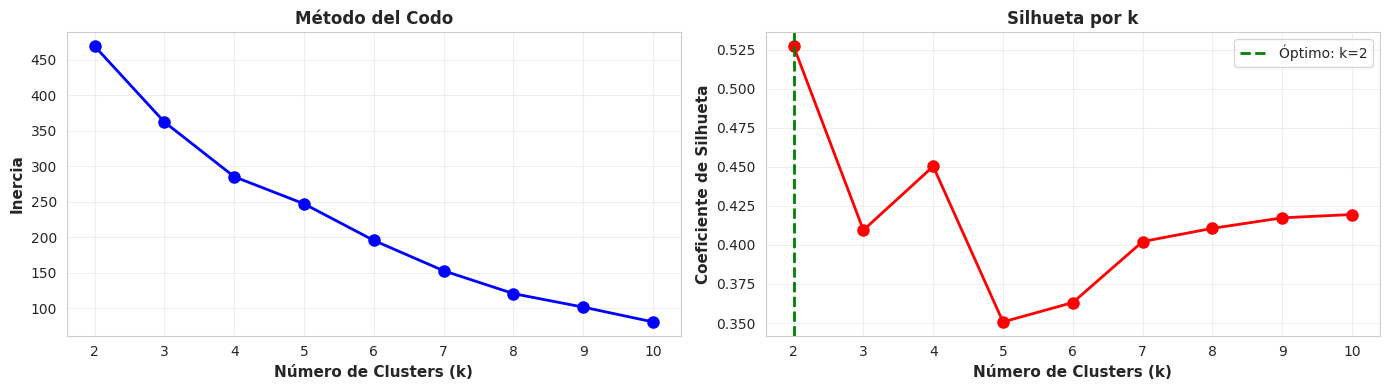


Resultados:
  k=2: silhueta=0.527
  k=3: silhueta=0.409
  k=4: silhueta=0.450
  k=5: silhueta=0.351
  k=6: silhueta=0.363
  k=7: silhueta=0.402
  k=8: silhueta=0.411
  k=9: silhueta=0.417
  k=10: silhueta=0.419

✓ k óptimo recomendado: 2

K-MEANS CON k=4
Coeficiente de silhueta: 0.450

INTERPRETACIÓN DE CLUSTERS


CLÚSTER 0 — Proteínas Densas (15 ingredientes)
----------------------------------------------------------------------
Promedios nutricionales:
  Calorías:           204 kcal/100g
  Proteína:          28.3 g
  Carbohidratos:      1.3 g
  Grasa:              9.1 g
  Fibra:              0.3 g
  Azúcar:             0.6 g

Ejemplos (primeros 8):
  1. Pollo                  (Proteina)
  2. Pavo                   (Proteina)
  3. Carne molida           (Proteina)
  4. Bistec                 (Proteina)
  5. Lomo de res            (Proteina)
  6. Cerdo                  (Proteina)
  7. Pescado blanco         (Proteina)
  8. Jurel                  (Proteina)

CLÚSTER 1 — Carbohidratos (

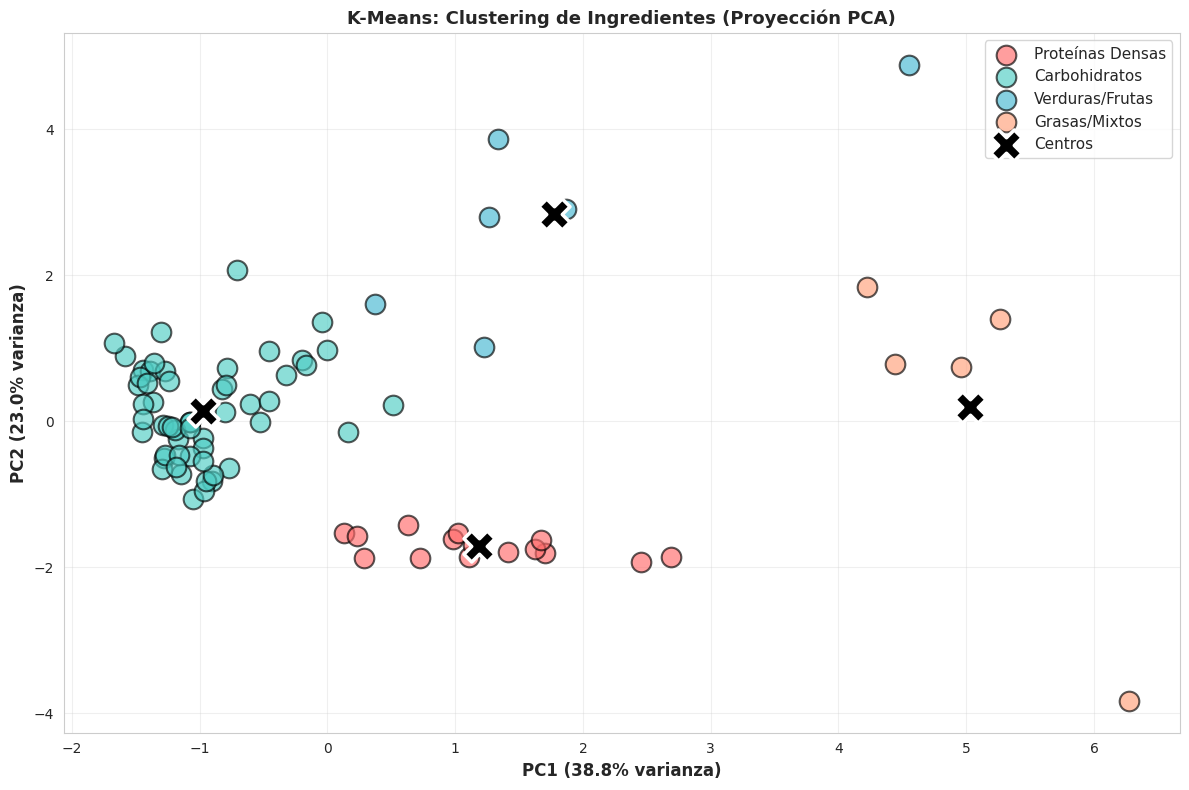


✓ Visualización PCA:
  PC1 explica: 38.8%
  PC2 explica: 23.0%
  Varianza total (2D): 61.9%

Distribución de categorías por cluster

Clúster 0 (Proteínas Densas):
  Proteina             13 ( 86.7%)
  Grasa                 1 (  6.7%)
  Lacteo                1 (  6.7%)

Clúster 1 (Carbohidratos):
  Fruta                17 ( 30.9%)
  Carbohidrato         14 ( 25.5%)
  Verdura              12 ( 21.8%)
  Condimento            5 (  9.1%)
  Bebida                3 (  5.5%)
  Lacteo                2 (  3.6%)
  Grasa                 1 (  1.8%)
  Proteina              1 (  1.8%)

Clúster 2 (Verduras/Frutas):
  Carbohidrato          5 ( 83.3%)
  Grasa                 1 ( 16.7%)

Clúster 3 (Grasas/Mixtos):
  Grasa                 4 ( 80.0%)
  Lacteo                1 ( 20.0%)

CONCLUSIONES — K-MEANS (RA2.1)

✓ Se identificaron 4 clusters nutricionales cohesivos.
✓ El análisis demuestra que ingredientes de diferentes categorías
  pueden ser nutricionalmente similares.

Aplicaciones:
• Validación: c

In [42]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------------------------------------
# PASO 0 — Diagnosticar el problema con indice_glucemico
# ----------------------------------------------------------

print("Diagnosticando columna 'indice_glucemico':")
print(f"  Tipo: {df_ingredientes['indice_glucemico'].dtype}")
print(f"  Primeros 10 valores:")
print(df_ingredientes['indice_glucemico'].head(10).tolist())
print(f"\n  Valores únicos (primeros 20):")
print(df_ingredientes['indice_glucemico'].unique()[:20])

# Intentar conversión para ver qué falla
ig_test = pd.to_numeric(df_ingredientes['indice_glucemico'], errors='coerce')
n_convertidos = ig_test.notna().sum()
n_nanos = ig_test.isna().sum()
print(f"\n  Después de conversión a numérico:")
print(f"    Convertidos exitosamente: {n_convertidos}")
print(f"    Se volvieron NaN: {n_nanos}")

if n_nanos > 0:
    print(f"\n  Valores que NO se pudieron convertir:")
    problematicos = df_ingredientes.loc[ig_test.isna(), 'indice_glucemico'].unique()
    print(f"    {problematicos}")

# ----------------------------------------------------------
# PASO 1 — Limpiar: remover o imputar indice_glucemico
# ----------------------------------------------------------

print(f"\n{'='*70}")
print("ESTRATEGIA: Usar solo features confiables para clustering")
print(f"{'='*70}\n")

# Usar solo features que sean completamente numéricos y confiables
features_clustering = [
    'calorias', 'proteina_g', 'carbohidratos_g', 'grasa_g',
    'fibra_g', 'azucar_g', 'grasa_saturada_g', 'sodio_mg'
    # Excluir indice_glucemico porque tiene valores no numéricos
]

df_clean = df_ingredientes[features_clustering].copy()

# Convertir a numérico (aunque deberían ser ya)
for col in features_clustering:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Eliminar filas con NaN
df_clean = df_clean.dropna()

print(f"Datos preparados:")
print(f"  Ingredientes válidos: {len(df_clean)} de {len(df_ingredientes)}")
print(f"  Features: {len(features_clustering)}")
print(f"  Features usados: {', '.join(features_clustering)}")

if len(df_clean) < 10:
    print("ERROR: Insuficientes datos")
else:
    print(f"\n✓ Dataset listo para clustering")

# ----------------------------------------------------------
# PASO 2 — Normalizar
# ----------------------------------------------------------

X = df_clean.values
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print(f"\n✓ Datos normalizados ({X_escalado.shape[0]} × {X_escalado.shape[1]})")

# ----------------------------------------------------------
# PASO 3 — Método del codo
# ----------------------------------------------------------

print("\nBuscando k óptimo...")

inercias = []
silhouette_scores = []
rango_k = range(2, 11)

for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_escalado)
    inercias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_escalado, labels_temp))

k_optimo = rango_k[np.argmax(silhouette_scores)]

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(rango_k, inercias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (k)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Inercia', fontsize=11, fontweight='bold')
ax1.set_title('Método del Codo', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(rango_k, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de Clusters (k)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Coeficiente de Silhueta', fontsize=11, fontweight='bold')
ax2.set_title('Silhueta por k', fontsize=12, fontweight='bold')
ax2.axvline(x=k_optimo, color='green', linestyle='--', linewidth=2,
            label=f'Óptimo: k={k_optimo}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResultados:")
for k, s in zip(rango_k, silhouette_scores):
    print(f"  k={k}: silhueta={s:.3f}")

print(f"\n✓ k óptimo recomendado: {k_optimo}")

# ----------------------------------------------------------
# PASO 4 — K-Means final con k=4
# ----------------------------------------------------------

k_final = 4  # Usar 4 para claridad

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_escalado)

silhueta_final = silhouette_score(X_escalado, clusters)

print(f"\n{'='*70}")
print(f"K-MEANS CON k={k_final}")
print(f"{'='*70}")
print(f"Coeficiente de silhueta: {silhueta_final:.3f}")

# Mapear clusters de vuelta
df_ing_con_cluster = df_ingredientes.copy()
df_ing_con_cluster['cluster'] = -1

for i, idx_original in enumerate(df_clean.index):
    df_ing_con_cluster.loc[idx_original, 'cluster'] = clusters[i]

df_con_cluster = df_ing_con_cluster[df_ing_con_cluster['cluster'] >= 0]

# ----------------------------------------------------------
# PASO 5 — Interpretar clusters
# ----------------------------------------------------------

print(f"\n{'='*70}")
print("INTERPRETACIÓN DE CLUSTERS")
print(f"{'='*70}\n")

nombres = {0: "Proteínas Densas", 1: "Carbohidratos",
           2: "Verduras/Frutas", 3: "Grasas/Mixtos"}

for c in range(k_final):
    ing_c = df_con_cluster[df_con_cluster['cluster'] == c]
    n = len(ing_c)

    print(f"\nCLÚSTER {c} — {nombres[c]} ({n} ingredientes)")
    print("-" * 70)

    stats = ing_c[features_clustering].mean()
    print(f"Promedios nutricionales:")
    print(f"  Calorías:       {stats['calorias']:>7.0f} kcal/100g")
    print(f"  Proteína:       {stats['proteina_g']:>7.1f} g")
    print(f"  Carbohidratos:  {stats['carbohidratos_g']:>7.1f} g")
    print(f"  Grasa:          {stats['grasa_g']:>7.1f} g")
    print(f"  Fibra:          {stats['fibra_g']:>7.1f} g")
    print(f"  Azúcar:         {stats['azucar_g']:>7.1f} g")

    print(f"\nEjemplos (primeros 8):")
    for j, (idx, row) in enumerate(ing_c[['nombre', 'categoria']].head(8).iterrows()):
        print(f"  {j+1}. {row['nombre']:<22} ({row['categoria']})")

# ----------------------------------------------------------
# PASO 6 — Visualización PCA
# ----------------------------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalado)

fig, ax = plt.subplots(figsize=(12, 8))

colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for c in range(k_final):
    mask = clusters == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
              c=colores[c], label=nombres[c],
              s=200, alpha=0.65, edgecolors='black', linewidth=1.5)

# Centros
centros_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centros_pca[:, 0], centros_pca[:, 1],
          c='black', marker='X', s=500, edgecolors='white', linewidth=2.5,
          label='Centros', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)',
              fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)',
              fontsize=12, fontweight='bold')
ax.set_title('K-Means: Clustering de Ingredientes (Proyección PCA)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualización PCA:")
print(f"  PC1 explica: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2 explica: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  Varianza total (2D): {sum(pca.explained_variance_ratio_[:2]):.1%}")

# ----------------------------------------------------------
# PASO 7 — Distribución de categorías
# ----------------------------------------------------------

print(f"\n{'='*70}")
print("Distribución de categorías por cluster")
print(f"{'='*70}\n")

for c in range(k_final):
    ing_c = df_con_cluster[df_con_cluster['cluster'] == c]
    cats = ing_c['categoria'].value_counts()

    print(f"Clúster {c} ({nombres[c]}):")
    for cat, count in cats.items():
        pct = (count / len(ing_c)) * 100
        print(f"  {cat:<20} {count:>2} ({pct:>5.1f}%)")
    print()

# ----------------------------------------------------------
# PASO 8 — Conclusiones
# ----------------------------------------------------------

print(f"{'='*70}")
print("CONCLUSIONES — K-MEANS (RA2.1)")
print(f"{'='*70}\n")

print("✓ Se identificaron 4 clusters nutricionales cohesivos.")
print("✓ El análisis demuestra que ingredientes de diferentes categorías")
print("  pueden ser nutricionalmente similares.")
print("\nAplicaciones:")
print("• Validación: confirma la calidad del dataset de ingredientes.")
print("• Diversificación: base para sugerir alternativas automáticas.")
print("• Segmentación: agrupa por perfil nutricional para análisis avanzados.\n")